In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# CRC cohort PDOX-seq

## Getting data from arrayExpress: E-MTAB-16585

In [3]:
# Download data from arrayExpress and reassemble anndata object
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16585"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16585 in: ../data_arrayExpress/E-MTAB-16585
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16585
      Inferred 2 dataset representations:
      - epi (full prefix: biobank_subcut_epi)
      - full (full prefix: biobank_subcut_full)
      Selected dataset for in-memory loading: epi (full prefix: biobank_subcut_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_full.h5ad
      Loading selected dataset from disk: E-MTAB-16585/E-MTAB-16585_epi.h5ad


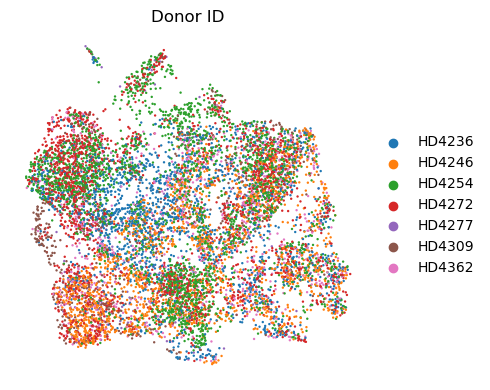

In [6]:
# Donor id UMAP
sc.pl.umap(
    adata,
    color="donor_id",
    title = "Donor ID",
    show=False,
    frameon=False,
)

fig = plt.gcf()
fig.set_size_inches(5, 4)
plt.tight_layout()
plt.show()

## EMP1 TACSTD2 composition

In [7]:
# Add EMP1 / TROP2 status
from utils import add_EMP1_status
adata = add_EMP1_status(adata)

In [8]:
# Set color code and plot barplot
from utils_biobank_subcut import color_code
adata = set_color_code(adata, color_code, feature='EMP1_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_3092836/574903803.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['EMP1_status']


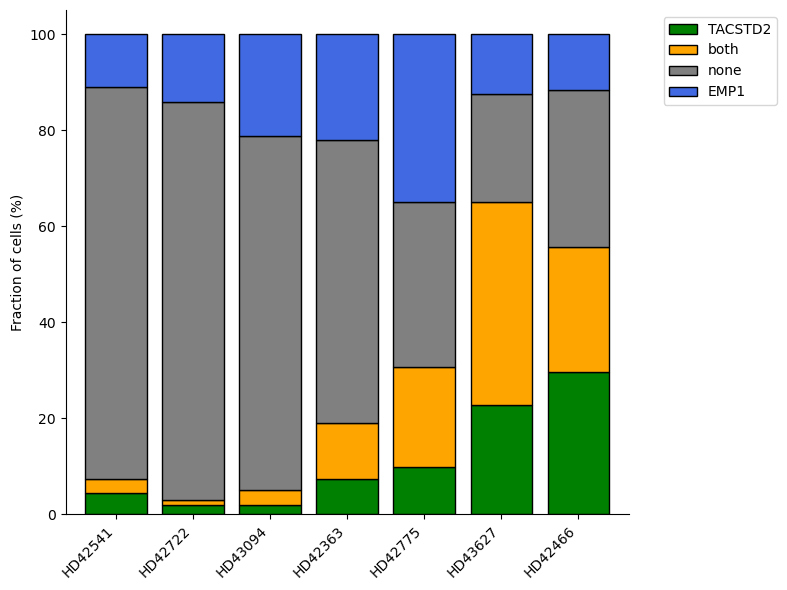

In [9]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['EMP1_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on TACSTD2 levels in ascending order
df = df.sort_values(by='TACSTD2', ascending=True)

# Sort DataFrame based on predefined donor order
# Swap order of HD43094 and HD42775 to match current Figure panel
order_donor_id = [ # order as in current Figure panel
    'HD4254', 'HD4272', 'HD4309', 'HD4236', 'HD4277', 'HD4362', 'HD4246',
]
# Reorder df by 'donor_id' column
df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1N
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['EMP1_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
df.to_csv(f"../data_suppl/{accession}_Ext_Fig_01k.csv")
df

EMP1_status,TACSTD2,both,none,EMP1
donor_id,,,,
HD4254,4.341085,2.868217,81.782946,11.007752
HD4272,1.897533,0.996205,83.017078,14.089184
HD4309,1.937407,3.129657,73.770492,21.162444
HD4236,7.297297,11.675676,58.972973,22.054054
HD4277,9.895833,20.833333,34.375000,34.895833
HD4362,22.713864,42.379548,22.418879,12.487709
HD4246,29.528247,26.033780,32.731508,11.706465


## Gene expression UMAP

UMAPs of gene expression patterns:


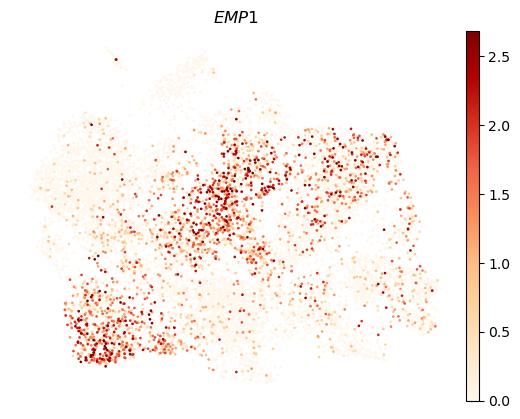

<Figure size 400x400 with 0 Axes>

In [11]:
# Features to plot
features = ['EMP1']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    fig = plt.gcf()
    fig.set_size_inches(4, 4)
    plt.tight_layout()
    plt.show()

# Public data: SMC and KUL cohorts

In [10]:
dir_data = "../data/"

In [11]:
# Read input data
file = os.path.join(dir_data, "SMC_epi.h5ad")
smc = sc.read_h5ad(file)

In [12]:
# Read input data
file = os.path.join(dir_data, "KUL_epi.h5ad")
kul = sc.read_h5ad(file)

## Stem cell composition

In [13]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
smc = add_SC_status(smc)
kul = add_SC_status(kul)

In [14]:
# Set color code and plot barplot
from utils_biobank_tissue import color_code
smc = set_color_code(smc, color_code, feature='SC_status')
kul = set_color_code(kul, color_code, feature='SC_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

SC_status        LGR5      both       none   TACSTD2
Patient ID                                          
SMC10-T     11.452514  0.000000  88.547486  0.000000
SMC24-T     37.500000  1.736111  59.722222  1.041667
SMC09-T     20.512821  0.284900  77.150997  2.051282
SMC08-T     16.500000  0.000000  81.000000  2.500000
SMC25-T     27.914110  1.840491  64.110429  6.134969


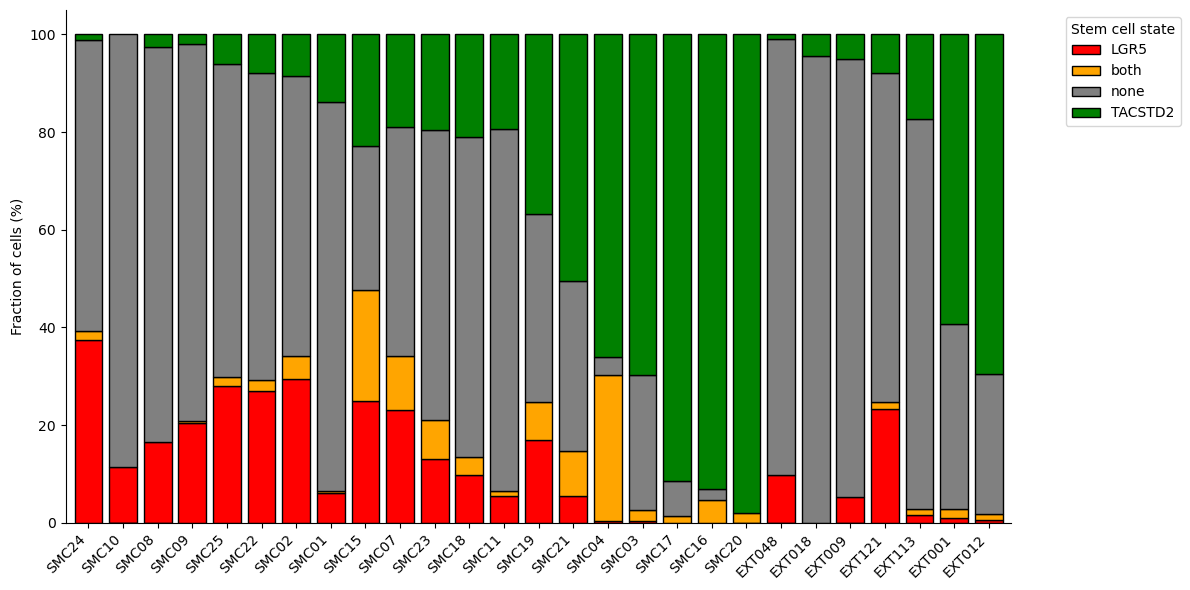

In [15]:
groupby = 'Patient ID'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df_smc = (
    smc.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)
df_smc = df_smc.sort_values(by='TACSTD2', ascending=True)

df_kul = (
    kul.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)
df_kul = df_kul.sort_values(by='TACSTD2', ascending=True)

# Combine both datasets
df = pd.concat([df_smc, df_kul], axis=0)
print(df.head())

# # Sort DataFrame based on predefined donor order
order_sample_id = [
    "SMC24-T", "SMC10-T", "SMC08-T", "SMC09-T", "SMC25-T", "SMC22-T",
    "SMC02-T", "SMC01-T", "SMC15-T", "SMC07-T", "SMC23-T", "SMC18-T",
    "SMC11-T", "SMC19-T", "SMC21-T", "SMC04-T", "SMC03-T", "SMC17-T",
    "SMC16-T", "SMC20-T",
    "EXT048", "EXT018", "EXT009", "EXT121", "EXT113", "EXT001", "EXT012"
]
df = df.reindex(order_sample_id)

# Barplot mimicking Fig S1M
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(12, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([donor.split("-")[0] for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
df.to_csv(f"../data_suppl/SMC_KUL_Ext_Fig_01m.csv")
df

SC_status,LGR5,both,none,TACSTD2
Patient ID,,,,
SMC24-T,37.500000,1.736111,59.722222,1.041667
SMC10-T,11.452514,0.000000,88.547486,0.000000
SMC08-T,16.500000,0.000000,81.000000,2.500000
SMC09-T,20.512821,0.284900,77.150997,2.051282
SMC25-T,27.914110,1.840491,64.110429,6.134969
SMC22-T,27.073733,2.246544,62.730415,7.949309
SMC02-T,29.391892,4.729730,57.432432,8.445946
SMC01-T,6.012658,0.527426,79.535865,13.924051
SMC15-T,24.911032,22.775801,29.537367,22.775801


# CRC cohort tissue-seq

## Getting data from arrayExpress: E-MTAB-16583

In [17]:
# Download data from arrayExpress and reassemble anndata object
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16583"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16583 in: ../data_arrayExpress/E-MTAB-16583
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16583
      Inferred 2 dataset representations:
      - epi (full prefix: biobank_tissue_epi)
      - full (full prefix: biobank_tissue_full)
      Selected dataset for in-memory loading: epi (full prefix: biobank_tissue_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16583/E-MTAB-16583_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16583/E-MTAB-16583_full.h5ad
      Loading selected dataset from disk: E-MTAB-16583/E-MTAB-16583_epi.h5ad


## Stem cell composition

In [18]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [19]:
# Set color code and plot barplot
from utils_biobank_subcut import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

For the manuscript, the composition plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_1777133/913482307.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


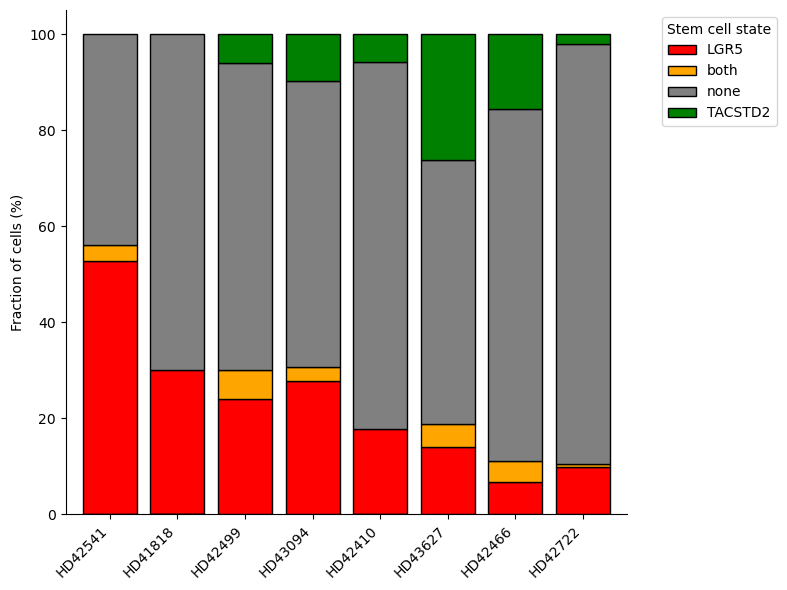

In [20]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on LGR5 levels in descending order
df = df.sort_values(by='LGR5', ascending=False)
# Sort DataFrame based on predefined donor order
df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1N
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
df.to_csv(f"../data_suppl/{accession}_Ext_Fig_01n.csv")
df

SC_status,LGR5,both,none,TACSTD2
donor_id,,,,
HD4254,52.631579,3.508772,43.859649,0.000000
HD4181,30.000000,0.000000,70.000000,0.000000
HD4249,24.000000,6.000000,64.000000,6.000000
HD4309,27.777778,2.777778,59.722222,9.722222
HD4241,17.647059,0.000000,76.470588,5.882353
HD4362,14.035088,4.824561,54.824561,26.315789
HD4246,6.666667,4.444444,73.333333,15.555556
HD4272,9.797297,0.675676,87.500000,2.027027


# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [22]:
session_info.show()

/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
